# Analisis de Delitos CABA 2020 - 2024

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from matplotlib.pyplot import tight_layout

In [8]:
PALETTE   = ["#2D6A9F", "#E07B39", "#3DAA6E", "#C94040", "#7B5EA7", "#5ABFBF"]
BG_COLOR  = "#F8F8F8"
TEXT_COLOR = "#2C2C2C"
GRID_COLOR = "#DDDDDD"

In [9]:
plt.rcParams.update({
    "figure.facecolor":  BG_COLOR,
    "axes.facecolor":    BG_COLOR,
    "axes.edgecolor":    GRID_COLOR,
    "axes.labelcolor":   TEXT_COLOR,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlecolor":   TEXT_COLOR,
    "xtick.color":       TEXT_COLOR,
    "ytick.color":       TEXT_COLOR,
    "grid.color":        GRID_COLOR,
    "grid.linewidth":    0.7,
    "font.family":       "sans-serif",
    "text.color":        TEXT_COLOR,
})

OUT = "./delitos_figures"

Carga de datos

In [10]:
dfs = []
for year in range(2020, 2025):
    df_y = pd.read_csv(f"./delitos_dataset/delitos_{year}.csv")
    dfs.append(df_y)
df = pd.concat(dfs, ignore_index=True)

# Orden de meses y dias

MES_ORDER = ["ENERO","FEBRERO","MARZO","ABRIL","MAYO","JUNIO",
             "JULIO","AGOSTO","SEPTIEMBRE","OCTUBRE","NOVIEMBRE","DICIEMBRE"]
DIA_ORDER = ["LUNES","MARTES","MIERCOLES","JUEVES","VIERNES","SABADO","DOMINGO"]

df["mes"] = pd.Categorical(df["mes"], categories=MES_ORDER, ordered=True)
df["dia"] = pd.Categorical(df["dia"], categories=DIA_ORDER)

YEARS = sorted(df["anio"].unique())
TIPOS = df["tipo"].value_counts().index.to_list()

## 1. Total de delitos por año

In [11]:
yearly = df.groupby("anio")["cantidad"].sum().reset_index()
var_pct = yearly["cantidad"].pct_change() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(yearly["anio"], yearly["cantidad"], color=PALETTE[0], width=0.55, zorder=3)
ax.plot(yearly["anio"], yearly["cantidad"], color=PALETTE[1], marker="o",
        linewidth=2, markersize=7, zorder=4)

for bar, val, pct in zip(bars, yearly["cantidad"], var_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1200,
            f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    if not np.isnan(pct):
        sign = "+" if pct > 0 else ""
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f"{sign}{pct:.1f}%", ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")

ax.set_title("Total de delitos por año")
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de delitos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks(YEARS)
ax.grid(axis="y", zorder=0)
ax.set_ylim(0, yearly["cantidad"].max() * 1.15)
fig.tight_layout()
fig.savefig(f"{OUT}/01_total_yearly.png", dpi=150)
plt.close()
print("01_total_yearly.png")

01_total_yearly.png


## 2. Distribucion por tipo de delito (total)

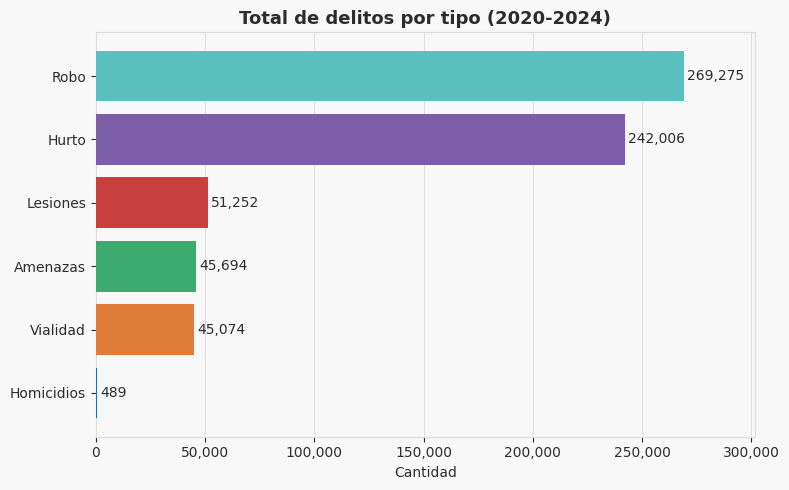

02_por_tipo.png


In [12]:
tipo_total = df.groupby("tipo")["cantidad"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(tipo_total.index, tipo_total.values,
               color=PALETTE[:len(tipo_total)], zorder=3)
for bar, val in zip(bars, tipo_total.values):
    ax.text(val + 1500, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=10)
ax.set_title("Total de delitos por tipo (2020-2024)")
ax.set_xlabel("Cantidad")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x", zorder=0)
ax.set_xlim(0, tipo_total.max() * 1.12)
fig.tight_layout()
fig.savefig(f"{OUT}/02_por_tipo.png", dpi=150)
plt.show()
plt.close()
print("02_por_tipo.png")

## 3. Evolucion interanual por tipo de delito

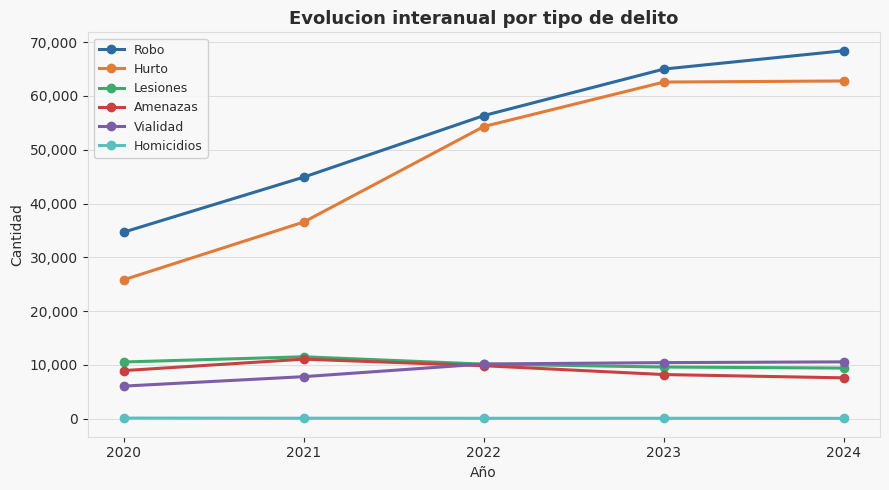

03_evolucion_interanual.png


In [13]:
year_type = df.groupby(["anio", "tipo"])["cantidad"].sum().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
for i, types in enumerate(TIPOS):
    sub = year_type[year_type["tipo"] == types]
    ax.plot(sub["anio"], sub["cantidad"], marker="o", linewidth=2.2,
            markersize=6, label=types, color=PALETTE[i % len(PALETTE)])
ax.set_title("Evolucion interanual por tipo de delito")
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks(YEARS)
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.grid(axis="y", zorder=0)
fig.tight_layout()
fig.savefig(f"{OUT}/03_evolucion_interanual.png", dpi=150)
plt.show()
plt.close()
print("03_evolucion_interanual.png")

## 4. Composicion por tipo de delito por año

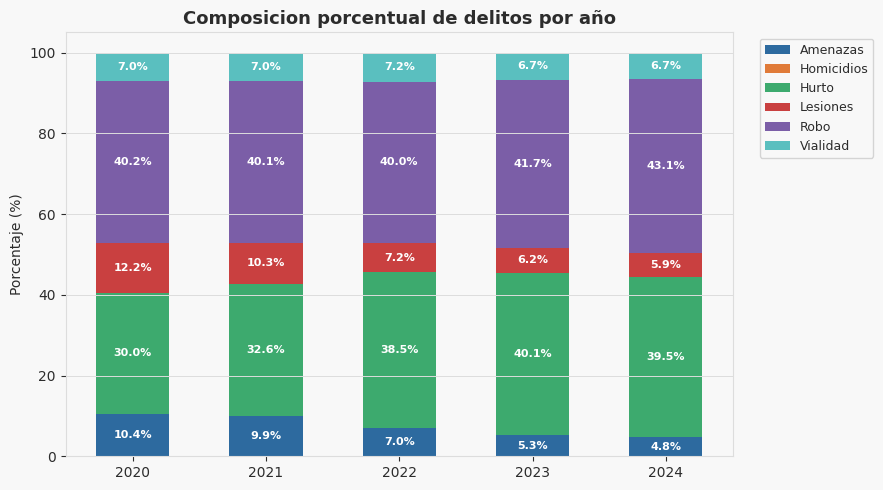

In [14]:
pivot = year_type.pivot(index="anio", columns="tipo", values="cantidad").fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(YEARS))
for i, col in enumerate(pivot_pct.columns):
    ax.bar(pivot_pct.index, pivot_pct[col], bottom=bottom, label=col, color=PALETTE[i % len(PALETTE)], width=0.55)
    for j, (y,b) in enumerate(zip(pivot_pct[col], bottom)):
        if y > 4:
            ax.text(YEARS[j], b + y/2, f"{y:.1f}%",
                    ha="center", va="center", fontsize=8,
                    color="white", fontweight="bold")
    bottom += pivot_pct[col].values

ax.set_title("Composicion porcentual de delitos por año")
ax.set_ylabel("Porcentaje (%)")
ax.set_xticks(YEARS)
ax.set_ylim(0, 105)
ax.legend(loc="upper right", fontsize=9, bbox_to_anchor=(1.22, 1))
ax.grid(axis="y", zorder=0)
fig.tight_layout()
fig.savefig(f"{OUT}/04_composicion.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

## 5. Distribucion mensual

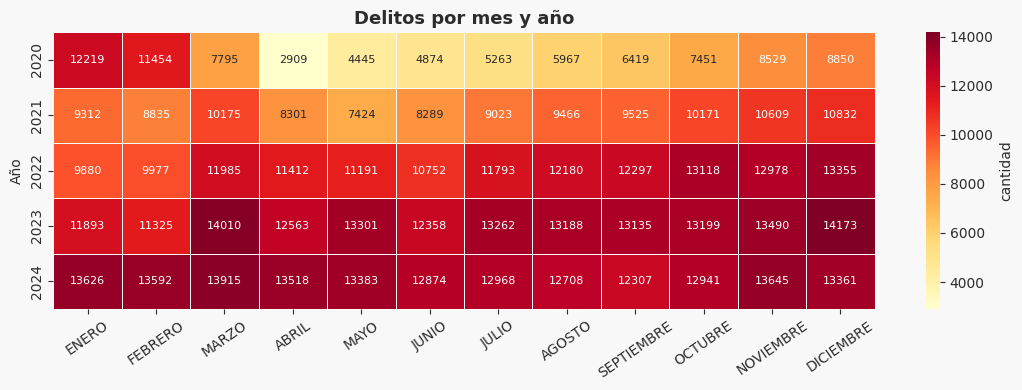

In [15]:
month_year = df.groupby(["anio", "mes"])["cantidad"].sum().reset_index()
pivot_month = month_year.pivot(index="anio", columns="mes", values="cantidad").fillna(0)
pivot_month = pivot_month[MES_ORDER]

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot_month, ax=ax, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.4, linecolor=BG_COLOR,
            annot_kws={"size": 8},
            cbar_kws={"label": "cantidad"})
ax.set_title("Delitos por mes y año")
ax.set_xlabel("")
ax.set_ylabel("Año")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
plt.savefig(f"{OUT}/05_heatmap_mes.png", dpi=150)
plt.show()
plt.close()

## 6. Distribucion por dia de la semana

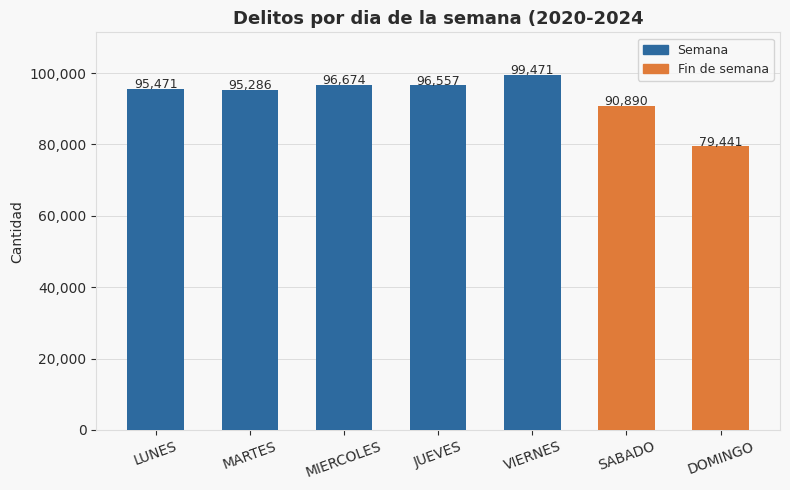

In [16]:
day_data = df.groupby("dia")["cantidad"].sum().reindex(DIA_ORDER)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [PALETTE[1] if d in ("SABADO", "DOMINGO") else PALETTE[0] for d in DIA_ORDER]
bars = ax.bar(day_data.index, day_data.values, color=colors, width=0.6, zorder=3)
for bar, val in zip(bars, day_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{val:,}", ha="center", fontsize=9)
ax.set_title("Delitos por dia de la semana (2020-2024")
ax.set_ylabel("Cantidad")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", zorder=0)
ax.set_ylim(0, day_data.max() * 1.12)

# manual legend for weekend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=PALETTE[0], label="Semana"),
                   Patch(color=PALETTE[1], label="Fin de semana")], fontsize=9)
fig.tight_layout()
fig.savefig(f"{OUT}/06_dia_semana.png", dpi=150)
plt.show()
plt.close()

## 7. Distribucion por franja horaria

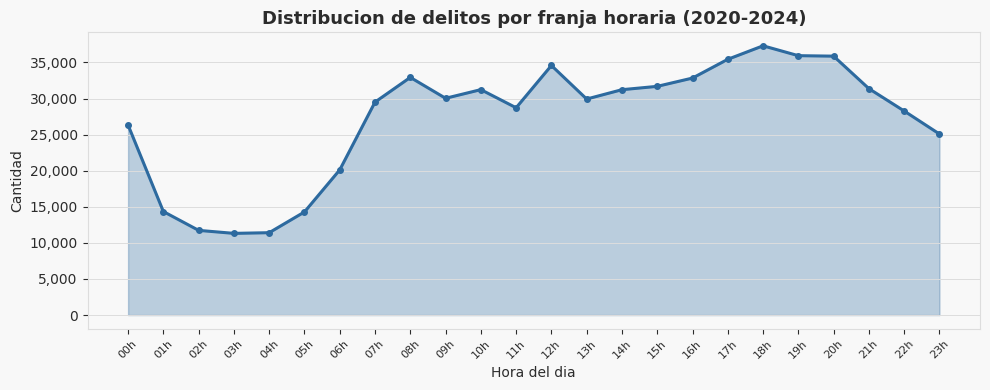

In [17]:
franja = df.groupby("franja")["cantidad"].sum().reindex(range(24)).fillna(0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(franja.index, franja.values, alpha=0.3, color=PALETTE[0])
ax.plot(franja.index, franja.values, color=PALETTE[0], linewidth=2.2, marker="o", markersize=4)
ax.set_title("Distribucion de delitos por franja horaria (2020-2024)")
ax.set_xlabel("Hora del dia")
ax.set_ylabel("Cantidad")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}h" for h in range(24)], rotation=45, fontsize=8)
ax.grid(axis="y", zorder=0)
fig.tight_layout()
fig.savefig(f"{OUT}/07_distribucion_horarias.png", dpi=150)
plt.show()
plt.close()

## 8. Top 10 barrios con mas delitos

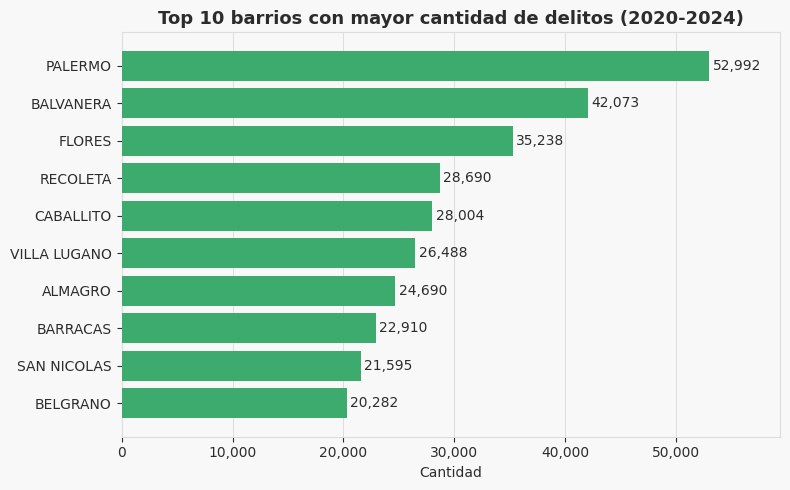

In [18]:
top_barrios = df.groupby("barrio")["cantidad"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(top_barrios.index[::-1], top_barrios.values[::-1],
               color=PALETTE[2], zorder=3)
for bar, val in zip(bars, top_barrios.values[::-1]):
    ax.text(val + 300, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=10)
ax.set_title("Top 10 barrios con mayor cantidad de delitos (2020-2024)")
ax.set_xlabel("Cantidad")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x", zorder=0)
ax.set_xlim(0, top_barrios.max() * 1.12)
fig.tight_layout()
fig.savefig(f"{OUT}/08_top_barrios.png", dpi=150)
plt.show()
plt.close()

## 9. Uso de arma y moto

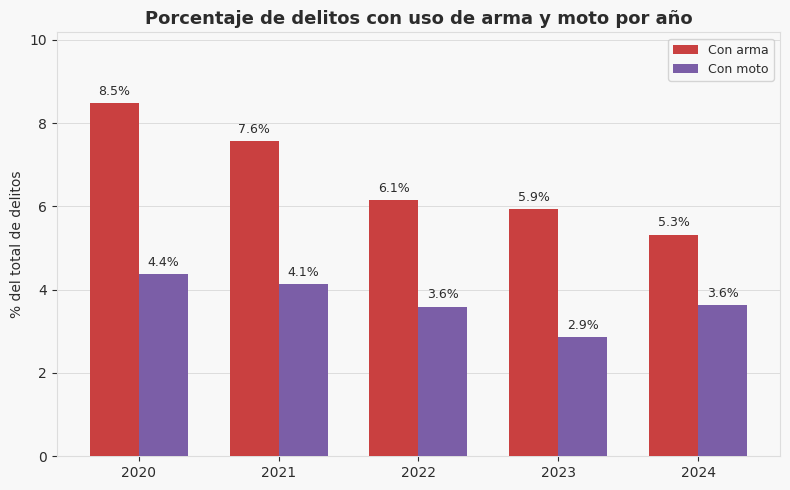

In [19]:
arma = df.groupby("anio").apply(lambda x: (x["uso_arma"] =="SI").sum()).reset_index(name="con_arma")
moto = df.groupby("anio").apply(lambda x: (x["uso_moto"] == "SI").sum()).reset_index(name="con_moto")
total_y = df.groupby("anio")["cantidad"].sum().reset_index(name="total")
arma_moto = arma.merge(moto, on="anio").merge(total_y, on="anio")
arma_moto["pct_arma"] = arma_moto["con_arma"] / arma_moto["total"] * 100
arma_moto["pct_moto"] = arma_moto["con_moto"] / arma_moto["total"] * 100

x = np.arange(len(YEARS))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, arma_moto["pct_arma"], width, label="Con arma", color=PALETTE[3], zorder=3)
b2 = ax.bar(x + width/2, arma_moto["pct_moto"], width, label="Con moto", color=PALETTE[4], zorder=3)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.2,
            f"{h:.1f}%", ha="center", fontsize=9)
ax.set_title("Porcentaje de delitos con uso de arma y moto por año")
ax.set_ylabel("% del total de delitos")
ax.set_xticks(x)
ax.set_xticklabels(YEARS)
ax.legend(fontsize=9)
ax.grid(axis="y", zorder=0)
ax.set_ylim(0, max(arma_moto["pct_arma"].max(), arma_moto["pct_moto"].max()) * 1.2)
fig.tight_layout()
fig.savefig(f"{OUT}/09_arma_moto.png", dpi=150)
plt.show()
plt.close()

## 10. Variacion interanual por tipo (%)

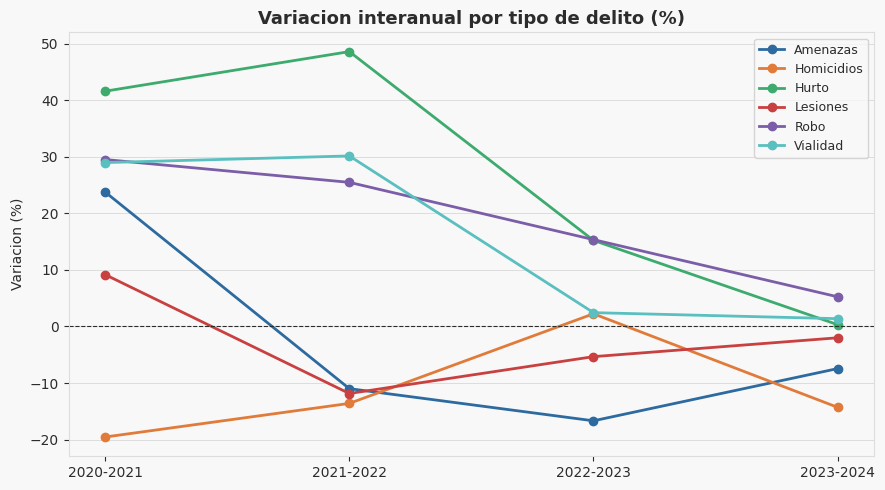

In [20]:
year_type = df.groupby(["anio", "tipo"])["cantidad"].sum().reset_index()
var_type = year_type.pivot(index="anio", columns="tipo", values="cantidad").pct_change() * 100
var_type = var_type.dropna()

fig, ax = plt.subplots(figsize=(9, 5))
for i, col in enumerate(var_type.columns):
    ax.plot(var_type.index, var_type[col], marker="o", linewidth=2,
            markersize=6, label=col, color=PALETTE[i % len(PALETTE)])
ax.axhline(0, color=TEXT_COLOR, linewidth=0.8, linestyle="--")
ax.set_title("Variacion interanual por tipo de delito (%)")
ax.set_ylabel("Variacion (%)")
ax.set_xticks(var_type.index)
ax.set_xticklabels([f"{int(a-1)}-{int(a)}" for a in var_type.index])
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", zorder=0)
fig.tight_layout()
fig.savefig(f"{OUT}/10_variacion_interanual.png", dpi=150)
plt.show()
plt.close()

In [21]:
stats = yearly.copy()
stats["var_pct"] = stats["cantidad"].pct_change() * 100
stats.to_csv("./stats_anual.csv", index=False)

tipo_anio_pivot = year_type.pivot(index="anio", columns="tipo", values="cantidad")
tipo_anio_pivot.to_csv("./stats_tipo_anio")

arma_moto.to_csv("./stats_arma_moto.csv", index=False)